# ChestMNIST Naive Single-Branch ANN on Colab

Notebook n?y ch?y ??c l?p tr?n Colab cho b?i to?n ChestMNIST multi-label. M? h?nh l? baseline naive: raw pixel 28x28 flatten th?nh vector 784, ?i qua MLP th??ng, kh?ng HOG, kh?ng deslant, kh?ng two-branch.


In [1]:
import os
from pathlib import Path

IN_COLAB = 'COLAB_GPU' in os.environ
save_root = Path('/content')

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    preferred_roots = [
        Path('/content/drive/MyDrive/Colab Experiments/Lab3-LT'),
        Path('/content/drive/MyDrive/Lab3-LT'),
        Path('/content/drive/MyDrive/Colab Notebooks/Lab3-LT'),
    ]
    for candidate in preferred_roots:
        candidate.mkdir(parents=True, exist_ok=True)
        save_root = candidate
        break

artifact_dir = save_root / 'artifacts' / 'chestmnist_naive_single_branch'
data_root = save_root / 'data' / 'chestmnist'
artifact_dir.mkdir(parents=True, exist_ok=True)
data_root.mkdir(parents=True, exist_ok=True)
print('save_root =', save_root)
print('artifact_dir =', artifact_dir)
print('data_root =', data_root)


Mounted at /content/drive
save_root = /content/drive/MyDrive/Colab Experiments/Lab3-LT
artifact_dir = /content/drive/MyDrive/Colab Experiments/Lab3-LT/artifacts/chestmnist_naive_single_branch
data_root = /content/drive/MyDrive/Colab Experiments/Lab3-LT/data/chestmnist


In [2]:
if IN_COLAB:
    !pip install -q medmnist scikit-learn matplotlib
    !nvidia-smi


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.5 MB/s eta 0:00:00
Thu Mar 26 07:06:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                 

In [3]:
import json
import random
from dataclasses import dataclass

import matplotlib.pyplot as plt
import medmnist
import numpy as np
import torch
import torch.nn as nn
from medmnist import INFO
from sklearn.metrics import roc_auc_score, f1_score
from torch.utils.data import DataLoader, Dataset

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

class ChestMnistRawDataset(Dataset):
    def __init__(self, images: np.ndarray, labels: np.ndarray) -> None:
        self.images = images.astype(np.float32) / 255.0
        self.labels = labels.astype(np.float32)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        image = self.images[idx].reshape(-1)
        label = self.labels[idx]
        return torch.from_numpy(image).float(), torch.from_numpy(label).float()

class NaiveChestAnn(nn.Module):
    def __init__(self, input_dim: int = 784, num_classes: int = 14) -> None:
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes),
        )
    def forward(self, x):
        return self.net(x)

@dataclass
class EpochResult:
    loss: float
    macro_auc: float
    macro_f1: float

def safe_macro_auc(y_true: np.ndarray, y_prob: np.ndarray) -> float:
    aucs = []
    for i in range(y_true.shape[1]):
        col = y_true[:, i]
        if np.unique(col).size < 2:
            continue
        aucs.append(roc_auc_score(col, y_prob[:, i]))
    return float(np.mean(aucs)) if aucs else 0.0

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_samples = 0
    all_probs = []
    all_labels = []
    with torch.no_grad():
        for features, labels in loader:
            features = features.to(device)
            labels = labels.to(device)
            logits = model(features)
            loss = criterion(logits, labels)
            probs = torch.sigmoid(logits)
            total_loss += loss.item() * labels.size(0)
            total_samples += labels.size(0)
            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    y_prob = np.concatenate(all_probs, axis=0)
    y_true = np.concatenate(all_labels, axis=0)
    y_pred = (y_prob >= 0.5).astype(np.float32)
    macro_auc = safe_macro_auc(y_true, y_prob)
    macro_f1 = float(f1_score(y_true, y_pred, average='macro', zero_division=0))
    return EpochResult(loss=total_loss / max(total_samples, 1), macro_auc=macro_auc, macro_f1=macro_f1), y_true, y_prob

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_samples = 0
    all_probs = []
    all_labels = []
    for features, labels in loader:
        features = features.to(device)
        labels = labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(features)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        probs = torch.sigmoid(logits)
        total_loss += loss.item() * labels.size(0)
        total_samples += labels.size(0)
        all_probs.append(probs.detach().cpu().numpy())
        all_labels.append(labels.cpu().numpy())
    y_prob = np.concatenate(all_probs, axis=0)
    y_true = np.concatenate(all_labels, axis=0)
    y_pred = (y_prob >= 0.5).astype(np.float32)
    macro_auc = safe_macro_auc(y_true, y_prob)
    macro_f1 = float(f1_score(y_true, y_pred, average='macro', zero_division=0))
    return EpochResult(loss=total_loss / max(total_samples, 1), macro_auc=macro_auc, macro_f1=macro_f1)

set_seed(42)
info = INFO['chestmnist']
ChestMNIST = getattr(medmnist, info['python_class'])

train_ds_raw = ChestMNIST(split='train', root=str(data_root), download=True, as_rgb=False)
val_ds_raw = ChestMNIST(split='val', root=str(data_root), download=True, as_rgb=False)
test_ds_raw = ChestMNIST(split='test', root=str(data_root), download=True, as_rgb=False)

train_images = np.asarray(train_ds_raw.imgs)
train_labels = np.asarray(train_ds_raw.labels)
val_images = np.asarray(val_ds_raw.imgs)
val_labels = np.asarray(val_ds_raw.labels)
test_images = np.asarray(test_ds_raw.imgs)
test_labels = np.asarray(test_ds_raw.labels)

print('train', train_images.shape, train_labels.shape)
print('val', val_images.shape, val_labels.shape)
print('test', test_images.shape, test_labels.shape)

train_ds = ChestMnistRawDataset(train_images, train_labels)
val_ds = ChestMnistRawDataset(val_images, val_labels)
test_ds = ChestMnistRawDataset(test_images, test_labels)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
batch_size = 512
epochs = 15
lr = 1e-3

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=device.type == 'cuda')
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=device.type == 'cuda')
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=device.type == 'cuda')

model = NaiveChestAnn().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

history = []
best_val_auc = -1.0
best_state = None
for epoch in range(1, epochs + 1):
    train_result = train_epoch(model, train_loader, criterion, optimizer, device)
    val_result, _, _ = evaluate(model, val_loader, criterion, device)
    row = {
        'epoch': epoch,
        'train_loss': train_result.loss,
        'train_macro_auc': train_result.macro_auc,
        'train_macro_f1': train_result.macro_f1,
        'val_loss': val_result.loss,
        'val_macro_auc': val_result.macro_auc,
        'val_macro_f1': val_result.macro_f1,
    }
    history.append(row)
    print(json.dumps(row, ensure_ascii=False))
    if val_result.macro_auc > best_val_auc:
        best_val_auc = val_result.macro_auc
        best_state = {k: v.cpu() for k, v in model.state_dict().items()}

model.load_state_dict(best_state)
val_result, _, _ = evaluate(model, val_loader, criterion, device)
test_result, test_true, test_prob = evaluate(model, test_loader, criterion, device)

metrics = {
    'best_val_macro_auc': best_val_auc,
    'final_val_macro_auc': val_result.macro_auc,
    'final_val_macro_f1': val_result.macro_f1,
    'test_macro_auc': test_result.macro_auc,
    'test_macro_f1': test_result.macro_f1,
    'epochs_ran': len(history),
    'history': history,
    'class_names': info['label'],
}
(artifact_dir / 'metrics.json').write_text(json.dumps(metrics, indent=2, ensure_ascii=False), encoding='utf-8')
np.save(artifact_dir / 'test_y_true.npy', test_true)
np.save(artifact_dir / 'test_y_prob.npy', test_prob)
torch.save({'model_state_dict': best_state, 'metrics': metrics}, artifact_dir / 'model_best.pt')
print(json.dumps({'best_val_macro_auc': best_val_auc, 'test_macro_auc': test_result.macro_auc, 'test_macro_f1': test_result.macro_f1}, ensure_ascii=False))

epochs_axis = [row['epoch'] for row in history]
train_auc = [row['train_macro_auc'] for row in history]
val_auc = [row['val_macro_auc'] for row in history]
train_loss = [row['train_loss'] for row in history]
val_loss = [row['val_loss'] for row in history]
plt.figure(figsize=(10,4.8))
plt.subplot(1,2,1)
plt.plot(epochs_axis, train_auc, label='train AUC', color='#0b6e4f')
plt.plot(epochs_axis, val_auc, label='val AUC', color='#1d3557')
plt.xlabel('Epoch')
plt.ylabel('Macro AUC')
plt.title('ChestMNIST naive ANN macro AUC')
plt.grid(alpha=0.25)
plt.legend()
plt.subplot(1,2,2)
plt.plot(epochs_axis, train_loss, label='train loss', color='#c1121f')
plt.plot(epochs_axis, val_loss, label='val loss', color='#f4a261')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('ChestMNIST naive ANN loss')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(artifact_dir / 'training_curves.png', dpi=200, bbox_inches='tight')
plt.close()


100%|██████████| 82.8M/82.8M [00:05<00:00, 15.8MB/s]


train (78468, 28, 28) (78468, 14)
val (11219, 28, 28) (11219, 14)
test (22433, 28, 28) (22433, 14)
{"epoch": 1, "train_loss": 0.1951225258350348, "train_macro_auc": 0.5386098551083165, "train_macro_f1": 0.0035354095270211483, "val_loss": 0.17780584494573928, "val_macro_auc": 0.5832046739521223, "val_macro_f1": 0.0}
{"epoch": 2, "train_loss": 0.17833605372815187, "train_macro_auc": 0.592448279237159, "train_macro_f1": 1.0264200521421387e-05, "val_loss": 0.17519559251193173, "val_macro_auc": 0.610593368074157, "val_macro_f1": 0.0}
{"epoch": 3, "train_loss": 0.17652224529611107, "train_macro_auc": 0.6154450517758017, "train_macro_f1": 0.0, "val_loss": 0.17396404131634668, "val_macro_auc": 0.6300856015071398, "val_macro_f1": 0.00021174477696216825}
{"epoch": 4, "train_loss": 0.17533259189243727, "train_macro_auc": 0.6332196601937919, "train_macro_f1": 0.0001897662909081477, "val_loss": 0.17325406684861888, "val_macro_auc": 0.6470124969699397, "val_macro_f1": 0.0004402377283733216}
{"epoch"

In [9]:
extra_epochs = 15

model = NaiveChestAnn().to(device)
ckpt = torch.load(artifact_dir / 'model_best.pt', map_location=device)
model.load_state_dict(ckpt['model_state_dict'])

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

extra_history = []
best_val_auc = metrics['best_val_macro_auc']
best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

start_epoch = len(history) + 1

for epoch in range(start_epoch, start_epoch + extra_epochs):
    train_result = train_epoch(model, train_loader, criterion, optimizer, device)
    val_result, _, _ = evaluate(model, val_loader, criterion, device)

    row = {
        'epoch': epoch,
        'train_loss': train_result.loss,
        'train_macro_auc': train_result.macro_auc,
        'train_macro_f1': train_result.macro_f1,
        'val_loss': val_result.loss,
        'val_macro_auc': val_result.macro_auc,
        'val_macro_f1': val_result.macro_f1,
    }
    history.append(row)
    extra_history.append(row)
    print(json.dumps(row, ensure_ascii=False))

    if val_result.macro_auc > best_val_auc:
        best_val_auc = val_result.macro_auc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

model.load_state_dict(best_state)
val_result, _, _ = evaluate(model, val_loader, criterion, device)
test_result, test_true, test_prob = evaluate(model, test_loader, criterion, device)

metrics = {
    'best_val_macro_auc': best_val_auc,
    'final_val_macro_auc': val_result.macro_auc,
    'final_val_macro_f1': val_result.macro_f1,
    'test_macro_auc': test_result.macro_auc,
    'test_macro_f1': test_result.macro_f1,
    'epochs_ran': len(history),
    'history': history,
    'class_names': info['label'],
}

(artifact_dir / 'metrics.json').write_text(json.dumps(metrics, indent=2, ensure_ascii=False), encoding='utf-8')
np.save(artifact_dir / 'test_y_true.npy', test_true)
np.save(artifact_dir / 'test_y_prob.npy', test_prob)
torch.save({'model_state_dict': best_state, 'metrics': metrics}, artifact_dir / 'model_best.pt')

print(json.dumps({
    'best_val_macro_auc': best_val_auc,
    'test_macro_auc': test_result.macro_auc,
    'test_macro_f1': test_result.macro_f1
}, ensure_ascii=False))


{"epoch": 31, "train_loss": 0.16674180875305444, "train_macro_auc": 0.7202223834024316, "train_macro_f1": 0.0054618341011381955, "val_loss": 0.16631730060221858, "val_macro_auc": 0.7137781998695346, "val_macro_f1": 0.005248697947671083}
{"epoch": 32, "train_loss": 0.16666873999723522, "train_macro_auc": 0.720355775977301, "train_macro_f1": 0.005817035982907688, "val_loss": 0.16632640896787915, "val_macro_auc": 0.7136804122812853, "val_macro_f1": 0.004266895228157782}
{"epoch": 33, "train_loss": 0.16659674920829518, "train_macro_auc": 0.721266015699631, "train_macro_f1": 0.005790675996377036, "val_loss": 0.16631105966412432, "val_macro_auc": 0.7135670626495532, "val_macro_f1": 0.0061506445602482395}
{"epoch": 34, "train_loss": 0.1665085466084765, "train_macro_auc": 0.7219912302956973, "train_macro_f1": 0.006035682676381859, "val_loss": 0.16616673363127463, "val_macro_auc": 0.715187329218158, "val_macro_f1": 0.004867726652566555}
{"epoch": 35, "train_loss": 0.1664636941778494, "train_mac

In [10]:
import json
metrics = json.loads((artifact_dir / 'metrics.json').read_text(encoding='utf-8'))
print('best_val_macro_auc =', metrics['best_val_macro_auc'])
print('test_macro_auc =', metrics['test_macro_auc'])
print('test_macro_f1 =', metrics['test_macro_f1'])


best_val_macro_auc = 0.7184568274521037
test_macro_auc = 0.7088402905295775
test_macro_f1 = 0.006860103755597846


In [ ]:
!ls -lah "$artifact_dir"


total 4.6M
-rw------- 1 root root  14K Mar 26 07:12 metrics.json
-rw------- 1 root root 2.1M Mar 26 07:12 model_best.pt
-rw------- 1 root root 1.2M Mar 26 07:12 test_y_prob.npy
-rw------- 1 root root 1.2M Mar 26 07:12 test_y_true.npy
-rw------- 1 root root 136K Mar 26 07:07 training_curves.png


artifact_dir = /content/drive/MyDrive/Colab Experiments/Lab3-LT/artifacts/chestmnist_naive_single_branch
epochs_ran = 45
last_epoch = 45
best_val_macro_auc = 0.7184568274521037
test_macro_auc = 0.7088402905295775
test_macro_f1 = 0.006860103755597846


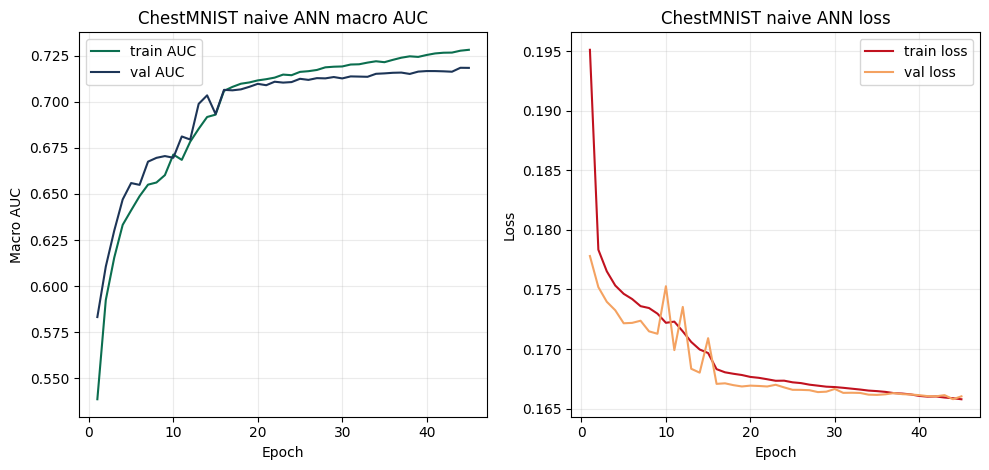

saved_plot = /content/drive/MyDrive/Colab Experiments/Lab3-LT/artifacts/chestmnist_naive_single_branch/training_curves.png

Files in artifact_dir:
- metrics.json
- model_best.pt
- test_y_prob.npy
- test_y_true.npy
- training_curves.png


In [12]:
import json
import matplotlib.pyplot as plt
from pathlib import Path

metrics_path = artifact_dir / 'metrics.json'
metrics = json.loads(metrics_path.read_text(encoding='utf-8'))

print('artifact_dir =', artifact_dir)
print('epochs_ran =', metrics['epochs_ran'])
print('last_epoch =', metrics['history'][-1]['epoch'])
print('best_val_macro_auc =', metrics['best_val_macro_auc'])
print('test_macro_auc =', metrics['test_macro_auc'])
print('test_macro_f1 =', metrics['test_macro_f1'])

history = metrics['history']
epochs_axis = [row['epoch'] for row in history]
train_auc = [row['train_macro_auc'] for row in history]
val_auc = [row['val_macro_auc'] for row in history]
train_loss = [row['train_loss'] for row in history]
val_loss = [row['val_loss'] for row in history]

plt.figure(figsize=(10, 4.8))

plt.subplot(1, 2, 1)
plt.plot(epochs_axis, train_auc, label='train AUC', color='#0b6e4f')
plt.plot(epochs_axis, val_auc, label='val AUC', color='#1d3557')
plt.xlabel('Epoch')
plt.ylabel('Macro AUC')
plt.title('ChestMNIST naive ANN macro AUC')
plt.grid(alpha=0.25)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_axis, train_loss, label='train loss', color='#c1121f')
plt.plot(epochs_axis, val_loss, label='val loss', color='#f4a261')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('ChestMNIST naive ANN loss')
plt.grid(alpha=0.25)
plt.legend()

plt.tight_layout()
plot_path = artifact_dir / 'training_curves.png'
plt.savefig(plot_path, dpi=200, bbox_inches='tight')
plt.show()
plt.close()

print('saved_plot =', plot_path)
print('\nFiles in artifact_dir:')
for p in sorted(Path(artifact_dir).glob('*')):
    print('-', p.name)
